In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datetime import date, timedelta
import os
import warnings
from tqdm.notebook import tqdm
from House2O import general_use

print(os.getcwd())

notebook_dir = os.getcwd()
sys.path.insert(0, os.path.join(os.getcwd(), "House2O"))
print(sys.path[0])

if 'House2O' in sys.modules:
    del sys.modules['House2O']

c:\Users\Matti\Documents\GitHub\House2O\House2O
c:\Users\Matti\Documents\GitHub\House2O\House2O\House2O


Mode:       SINGLE DAY — 2024-03-21
Label:      Spring_fine
Days:       1  (2024-03-21 → 2024-03-21, step: 1 day(s))
Hours:      06:00 → 21:00, step: 1h
Angles:     35° → 45°, step: 1°
Resuming from cache — 16368 results already stored.
Total computations: 0



Processing: 0call [00:00, ?call/s]


  LABEL:                  Spring_fine
  OPTIMAL ANGLE (coarse): 38°
  Total absorbed energy:  126521.8 W


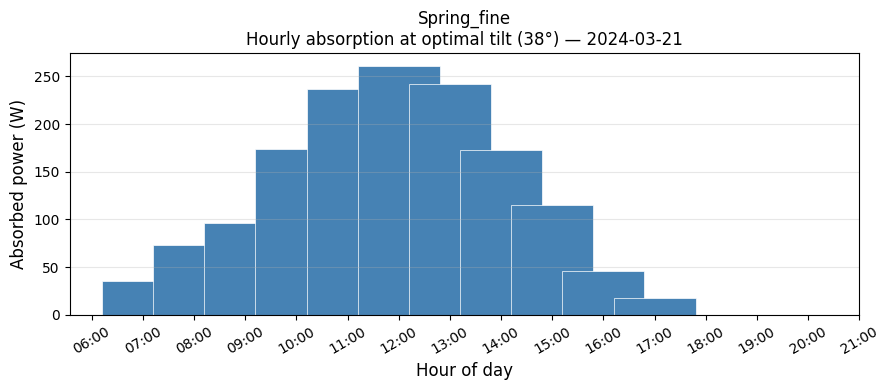

Saved: C:\Users\Matti\Documents\GitHub\House2O\output_plots\OptimalAngle\Spring_fine_2024-03-21_hourly_optimal.png


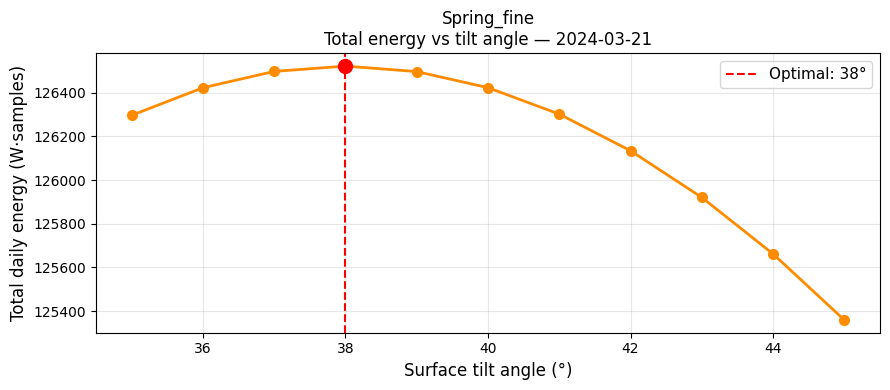

Saved: C:\Users\Matti\Documents\GitHub\House2O\output_plots\OptimalAngle\Spring_fine_2024-03-21_energy_vs_angle.png


In [2]:


# ALS JE IETS TEST, pas dan het LABEL AAAAAAAN
# ANDERS WORDEN DE RESULTATEN OVERSCHREVEN

# ============================================================
# CONFIGURATION
# ============================================================
LAT           = 51.222
LON           = 4.401
START_DATE    = date(2024, 3, 21)
END_DATE      = date(2024, 3, 21)      
HOURS         = list(range(6, 22, 1))
DAY_STEP      = 1
ANGLE_MIN     = 35
ANGLE_MAX     = 45
ANGLE_STEP    = 1
LABEL         = "Spring_fine"   
SAVE_DIR      = r"C:\Users\Matti\Documents\GitHub\House2O\output_plots\OptimalAngle"
CACHE_FILE    = os.path.join(SAVE_DIR, f"{LABEL.replace(' ', '_').replace('/', '-')}_cache.csv")
os.makedirs(SAVE_DIR, exist_ok=True)
# ============================================================

SINGLE_DAY = (START_DATE == END_DATE)

# ── Build day / angle lists ───────────────────────────────────
all_days, d = [], START_DATE
while d <= END_DATE:
    all_days.append(d)
    d += timedelta(days=DAY_STEP)

all_angles   = list(range(ANGLE_MIN, ANGLE_MAX + 1, ANGLE_STEP))
total_calls  = len(all_angles) * len(all_days) * len(HOURS)

# ── Display configuration ─────────────────────────────────────
HOUR_STEP_SIZE = HOURS[1] - HOURS[0]
date_range_str = str(START_DATE) if SINGLE_DAY else f"{START_DATE} → {END_DATE} (every {DAY_STEP} days)"

print(f"Mode:       {'SINGLE DAY' if SINGLE_DAY else 'MULTI-DAY'} — {date_range_str}")
print(f"Label:      {LABEL}")
print(f"Days:       {len(all_days)}  ({START_DATE} → {END_DATE}, step: {DAY_STEP} day(s))")
print(f"Hours:      {HOURS[0]:02d}:00 → {HOURS[-1]:02d}:00, step: {HOUR_STEP_SIZE}h")
print(f"Angles:     {ANGLE_MIN}° → {ANGLE_MAX}°, step: {ANGLE_STEP}°")


# ── Load or init cache ────────────────────────────────────────
if os.path.exists(CACHE_FILE):
    cache_df = pd.read_csv(CACHE_FILE)
    cache_df = cache_df.drop_duplicates(subset=["angle", "date", "hour"], keep="last")
    cache    = set(zip(cache_df["angle"], cache_df["date"], cache_df["hour"]))
    records  = cache_df.to_dict("records")
    print(f"Resuming from cache — {len(records)} results already stored.")
else:
    cache, records = set(), []
    print("Starting fresh.")

# ── Main sweep ────────────────────────────────────────────────
call_count = 0
total_remaining = max(0, total_calls-len(cache))
print(f"Total computations: {total_remaining:,}\n")

with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)

    bar = tqdm(
        total=total_remaining,
        desc="Processing",
        unit="call",
        dynamic_ncols=True,
    )

    for angle in all_angles:
        for day in all_days:
            day_str = day.strftime("%Y-%m-%d")
            for hour in HOURS:
                key = (angle, day_str, hour)
                if key in cache:
                    continue

                datetime_str = f"{day_str} {hour:02d}:00"
                try:
                    _, _, power = general_use(
                        LAT=LAT, LON=LON,
                        DATETIME=datetime_str,
                        surface_tilt=angle,
                        print_details=False,
                    )
                except Exception as e:
                    tqdm.write(f"  [ERROR] {datetime_str} angle={angle}°: {e}")
                    power = 0.0

                records.append({"angle": angle, "date": day_str, "hour": hour, "power": power})
                cache.add(key)
                call_count += 1
                bar.update(1)

        pd.DataFrame(records).to_csv(CACHE_FILE, index=False)

    bar.close()

# ── Aggregate ─────────────────────────────────────────────────
df               = pd.DataFrame(records)
df = df.drop_duplicates(subset=["angle", "date", "hour"], keep="last")
HOUR_STEP = HOURS[1] -HOURS[0]


def trapezoid_energy(group):
    g = group.sort_values("hour").dropna(subset = ["power"])
    return np.trapezoid(g["power"], dx = HOUR_STEP)

energy_per_angle = (df.groupby(["angle", "date"])
                    .apply(trapezoid_energy, include_groups = False)
                    .groupby("angle")
                    .sum()
                    .reset_index())

energy_per_angle.columns = ["angle", "total_energy_Wh-m2"]

best_row   = energy_per_angle.loc[energy_per_angle["total_energy_Wh-m2"].idxmax()]
best_angle = int(best_row["angle"])
best_power = best_row["total_energy_Wh-m2"]

print(f"\n{'='*55}")
print(f"  LABEL:                  {LABEL}")
print(f"  OPTIMAL ANGLE (coarse): {best_angle}°")
print(f"  Total absorbed energy:  {best_power:.1f} W")
print(f"{'='*55}")

# ── Safe filename fragment from label ─────────────────────────
label_slug = LABEL.replace(" ", "_").replace("/", "-")

# ══════════════════════════════════════════════════════════════
#  SINGLE-DAY PLOTS
# ══════════════════════════════════════════════════════════════
if SINGLE_DAY:
    day_str  = START_DATE.strftime("%Y-%m-%d")
    day_df   = df[df["date"] == day_str].copy()

    # --- Plot A: hourly power at the optimal angle -------------
    opt_df   = day_df[day_df["angle"] == best_angle].sort_values("hour")
    fig, ax  = plt.subplots(figsize=(9, 4))
    ax.bar(opt_df["hour"], opt_df["power"], width=1.6,
           color="steelblue", edgecolor="white", linewidth=0.5)
    ax.set_xlabel("Hour of day", fontsize=12)
    ax.set_ylabel("Absorbed power (W)", fontsize=12)
    ax.set_xticks(opt_df["hour"])
    ax.set_xticklabels([f"{h:02d}:00" for h in opt_df["hour"]], rotation=30)
    ax.set_title(
        f"{LABEL}\nHourly absorption at optimal tilt ({best_angle}°) — {day_str}",
        fontsize=12,
    )
    ax.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    fname = os.path.join(SAVE_DIR, f"{label_slug}_{day_str}_hourly_optimal.png")
    plt.savefig(fname, dpi=150)
    plt.show()
    print(f"Saved: {fname}")

    # --- Plot B: total daily energy per angle ------------------
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(energy_per_angle["angle"], energy_per_angle["total_energy_Wh-m2"],
            "o-", color="darkorange", lw=2, markersize=7)
    ax.axvline(best_angle, color="red", linestyle="--", lw=1.5,
               label=f"Optimal: {best_angle}°")
    ax.scatter([best_angle], [best_power], color="red", zorder=5, s=100)
    ax.set_xlabel("Surface tilt angle (°)", fontsize=12)
    ax.set_ylabel("Total daily energy (W·samples)", fontsize=12)
    ax.set_title(
        f"{LABEL}\nTotal energy vs tilt angle — {day_str}",
        fontsize=12,
    )
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    fname = os.path.join(SAVE_DIR, f"{label_slug}_{day_str}_energy_vs_angle.png")
    plt.savefig(fname, dpi=150)
    plt.show()
    print(f"Saved: {fname}")

# ══════════════════════════════════════════════════════════════
#  MULTI-DAY PLOTS  (unchanged logic, label added)
# ══════════════════════════════════════════════════════════════
else:
    # --- Plot 1: total energy vs angle ------------------------
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(energy_per_angle["angle"], energy_per_angle["total_energy_Wh-m2"],
            "o-", color="steelblue", lw=2, markersize=7)
    ax.axvline(best_angle, color="red", linestyle="--", lw=1.5,
               label=f"Optimal: {best_angle}°")
    ax.scatter([best_angle], [best_power], color="red", zorder=5, s=100)
    ax.set_xlabel("Surface Tilt Angle (°)", fontsize=12)
    ax.set_ylabel("Total Absorbed Energy (W·samples)", fontsize=12)
    ax.set_title(
        f"{LABEL}\nSeasonal Energy vs Tilt Angle ({ANGLE_STEP}° steps)\n"
        f"{START_DATE} → {END_DATE} | every {DAY_STEP} days | hours: {HOURS[0]}h–{HOURS[-1]}h",
        fontsize=12,
    )
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    fname = os.path.join(SAVE_DIR, f"{label_slug}_energy_vs_angle.png")
    plt.savefig(fname, dpi=150)
    plt.show()
    print(f"Saved: {fname}")

    # --- Plot 2: heatmap angle × day --------------------------
    pivot  = df.groupby(["angle", "date"])["power"].sum().unstack("date")
    fig, ax = plt.subplots(figsize=(16, 6))
    im = ax.imshow(pivot.values, aspect="auto", cmap="inferno", origin="lower",
                   extent=[0, len(pivot.columns), pivot.index.min(), pivot.index.max()])
    plt.colorbar(im, ax=ax, label="Daily Energy (W·samples)")
    ax.set_yticks(pivot.index)
    ax.set_yticklabels([f"{a}°" for a in pivot.index])
    n_dates  = len(pivot.columns)
    tick_pos = np.linspace(0, n_dates - 1, min(10, n_dates), dtype=int)
    ax.set_xticks(tick_pos)
    ax.set_xticklabels([list(pivot.columns)[i] for i in tick_pos],
                       rotation=45, ha="right")
    ax.set_xlabel("Date", fontsize=12)
    ax.set_ylabel("Tilt Angle (°)", fontsize=12)
    ax.set_title(
        f"{LABEL}\nHeatmap: Daily Energy per Angle — {START_DATE} → {END_DATE}",
        fontsize=12,
    )
    plt.tight_layout()
    fname = os.path.join(SAVE_DIR, f"{label_slug}_heatmap.png")
    plt.savefig(fname, dpi=150)
    plt.show()
    print(f"Saved: {fname}")